In the name of God

# Q2: Reconstruction of endoscopic polyp images with EndoVAE

In this notebook we are going to be reproducing the work done in this paper (https://www.researchgate.net/publication/361927238_EndoVAE_Generating_Endoscopic_Images_with_a_Variational_Autoencoder) but we are going to sue teh Kvasir dataset from kaggle instead (https://www.kaggle.com/datasets/meetnagadia/kvasir-dataset)

## 2-1. Data preprocessing 

For the first step we are going to preprocess the dataset by extracting the normal pictures from normal-z-line, normal-pylorus, normal-cecum folders and polyp images from polyp folders, change their color space to RGB, change their dimensions bilinearly to 96x96 and normalise them to [0, 1] range and perform some data augmentation and finally store them in a folder called preprocessed under the two classes of normal and polyp.

We will also visualise a few examples of images before and after this preprocessing.

In [1]:
import os
from PIL import Image
import torch
import torchvision.transforms as T
from tqdm import tqdm

dataset_path = './dataset' 
preprocessed_path = './processed'
image_size = 96
num_augmentation_per_polyp = 2

normal_folders = ['normal-cecum', 'normal-pylorus', 'normal-z-line']
polyp_folders = ['polyps'] 

polyp_augmentation_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
])

main_preprocess_transform = T.Compose([
    T.CenterCrop(480),
    T.Resize((image_size, image_size), interpolation=T.InterpolationMode.BILINEAR), 
    T.ToTensor()
])

output_normal_path = os.path.join(preprocessed_path, 'normal')
output_polyp_path = os.path.join(preprocessed_path, 'polyp')

os.makedirs(output_normal_path, exist_ok=True)
os.makedirs(output_polyp_path, exist_ok=True)

print("Processing normal images")
normal_image_paths = []
for folder in normal_folders:
    folder_path = os.path.join(dataset_path, folder)
    for image_name in os.listdir(folder_path):
        if image_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            normal_image_paths.append(os.path.join(folder_path, image_name))

for image_path in tqdm(normal_image_paths, desc="Normal Images"):
    try:
        image = Image.open(image_path).convert('RGB')
        processed_tensor = main_preprocess_transform(image)
        
        base_filename = os.path.splitext(os.path.basename(image_path))[0]
        output_filename = os.path.join(output_normal_path, f"{base_filename}.pt")
        torch.save(processed_tensor, output_filename)
    except Exception as e:
        print(f"Skipping file {image_path} due to error: {e}")

print("Processing polyp images")
polyp_image_paths = []
for folder in polyp_folders:
    folder_path = os.path.join(dataset_path, folder)
    for image_name in os.listdir(folder_path):
         if image_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            polyp_image_paths.append(os.path.join(folder_path, image_name))

total_polyps_processed = 0
for image_path in tqdm(polyp_image_paths, desc="Polyp Images"):
    try:
        image = Image.open(image_path).convert('RGB')
        base_filename = os.path.splitext(os.path.basename(image_path))[0]
        
        original_processed_tensor = main_preprocess_transform(image)
        output_filename_orig = os.path.join(output_polyp_path, f"{base_filename}.pt")
        torch.save(original_processed_tensor, output_filename_orig)
        total_polyps_processed += 1
        
        for i in range(num_augmentation_per_polyp):
            augmented_image = polyp_augmentation_transform(image)
            augmented_tensor = main_preprocess_transform(augmented_image)
            
            output_filename_aug = os.path.join(output_polyp_path, f"{base_filename}_aug_{i+1}.pt")
            torch.save(augmented_tensor, output_filename_aug)
            total_polyps_processed += 1
            
    except Exception as e:
        print(f"Skipping file {image_path} due to error: {e}")

Processing normal images


Normal Images: 100%|██████████| 1500/1500 [00:12<00:00, 117.91it/s]


Processing polyp images


Polyp Images: 100%|██████████| 500/500 [00:12<00:00, 40.96it/s]


Now that the images are ready we will show a few of them

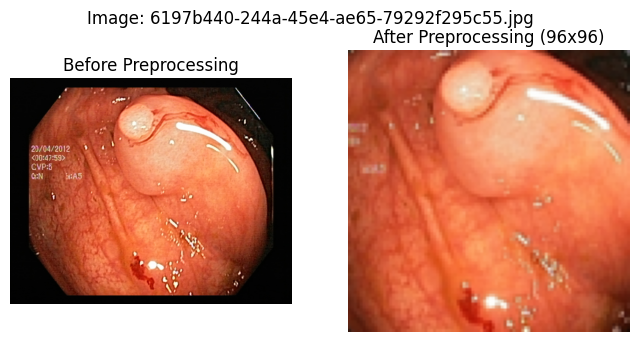

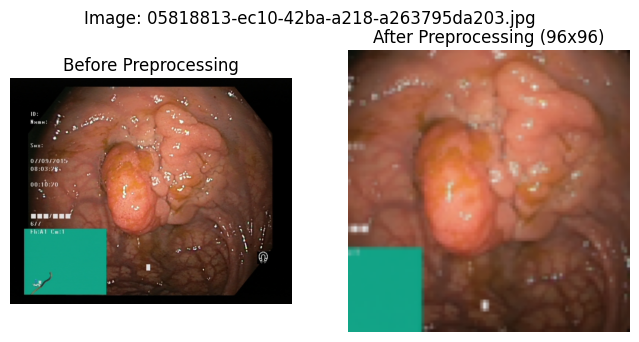

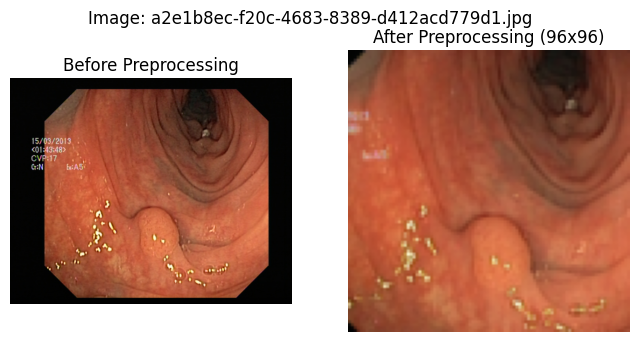

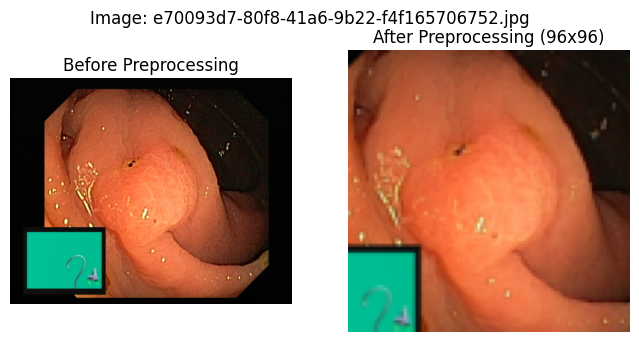

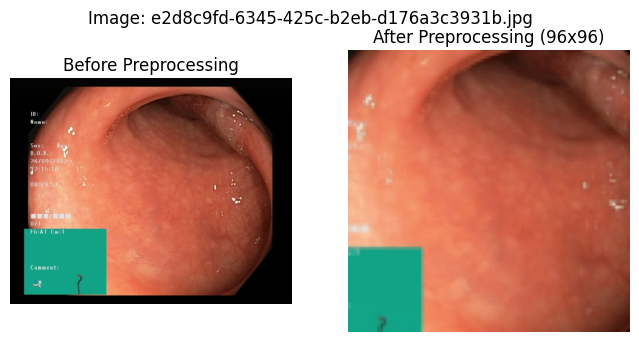

In [2]:
import matplotlib.pyplot as plt
import random

polyp_folders = ['polyps']
output_polyp_path = os.path.join(preprocessed_path, 'polyp')

def show_before_after(original_image_path, processed_tensor_path):

    original_img = Image.open(original_image_path).convert('RGB')
    
    processed_tensor = torch.load(processed_tensor_path)
    processed_img = T.ToPILImage()(processed_tensor)
    
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f"Image: {os.path.basename(original_image_path)}", y=0.95)
    
    ax[0].imshow(original_img)
    ax[0].set_title("Before Preprocessing")
    ax[0].axis('off')
    
    ax[1].imshow(processed_img)
    ax[1].set_title("After Preprocessing (96x96)")
    ax[1].axis('off')
    
    plt.show()


polyp_folder_path = os.path.join(dataset_path, random.choice(polyp_folders))
all_original_polyp_images = [
    f for f in os.listdir(polyp_folder_path) 
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

if len(all_original_polyp_images) >= 5:
    selected_image_names = random.sample(all_original_polyp_images, 5)

    for img_name in selected_image_names:
        original_path = os.path.join(polyp_folder_path, img_name)
        processed_filename = os.path.splitext(img_name)[0] + ".pt"
        processed_path = os.path.join(output_polyp_path, processed_filename)
        
        show_before_after(original_path, processed_path)

## 2-2. EndoVAE architecture

In this section we will explain the architecture of the EndoVAE as introduced in the paper and then implement it.

As with any other VAE, this model has three main components:

__1. The encoder__

The encoder compresses a high dimensional image (in our case 96x96x3) into a smaller set of features called the latent space. The six 2D convolution layers here act as feature extractors. As the image passes through them the dimension is reduced (when the stride is higher than 1) and this forces the model to learn abstract features. After this filtering the features are passed to a linear layer with 256 neurons for final preprocessing after which two separate linear layer, fc_mu and fc_logvar, map these features to the mean and log-variance of a gaussian distribution (which is the key difference between normal auto encoders and variational auto encoders)

__2. The reparameterization__

This is a clever trick that makes VAEs trainable. Since we are dealing with a random distribution rather than a fixed vector in VAEs we need to sample a point from this random distributions at this point, but random sampling has no gradient. The reparametrization trick solves this issue by separating the random part. We first sample a random number (vector) from a fixed standard normal distribution, which doesn't have any learnable parameters, then we scale this number (vector) by our learned standard deviation and shift it by our learned mean. This way the random part is external and the gradient can be calculated.

__3. The decoder__

The decoder's role is the reverse of the encoders, it takes a low dimensional vector from the latent space (form the previous layers) and attempts to reconstruct an image from it. It begins by using a linear layer to project the latent space into a larger tensor and create a base feature map from it then transpose convolution layers are used to slowly upsample this feature map and increase its size. Then another final convolution layer is used to condense all these feature maps into a 3 channel RGB image.

We will add all the layers according to this image from the paper and the section III of the paper where other details are motioned.

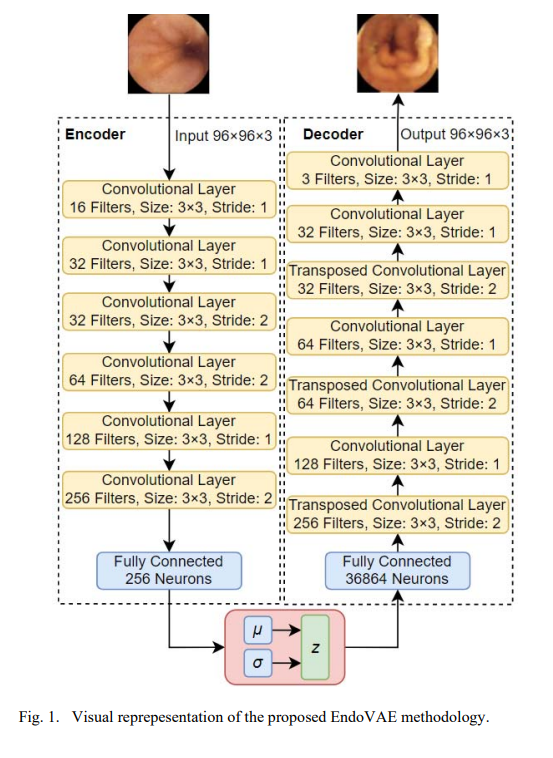

One important note here is despite the fact that the diagram shows the usage of a mix of transpose convolution and normal convolution, the text of the paper states : "The decoder part of the proposed model consists of a fully connected layer that contains 36,864 neurons followed by seven transpose convolutional layers with 256, 128, 64, 64, 32, 32 and 3 filters respectively" so I implemented the decoder part using only transpose convolution.

In [3]:
import torch.nn as nn

class EndoVAE(nn.Module):
    def __init__(self, latent_dim=6):
        super(EndoVAE, self).__init__()
        
        # Encoder 
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
        self.fc_after_flatten = nn.Linear(256 * 12 * 12, 256)
        
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        
        # Decoder 
        self.decoder_input = nn.Linear(latent_dim, 256 * 12 * 12)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std) 
        return mu + std * epsilon

    def forward(self, x):
        # Encode
        encoded = self.encoder(x)
        encoded = torch.flatten(encoded, start_dim=1)
        encoded = self.fc_after_flatten(encoded)
        
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        
        # Reparameterize
        z = self.reparameterize(mu, logvar)
        
        # Decode
        decoded = self.decoder_input(z)
        decoded = decoded.view(-1, 256, 12, 12)
        reconstructed_x = self.decoder(decoded)
        
        return reconstructed_x, x, mu, logvar

model = EndoVAE(latent_dim=6)
print(model)

EndoVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (11): ReLU()
  )
  (fc_after_flatten): Linear(in_features=36864, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=6, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=6, bias=True)
  (decoder_input): Linear(in_features=6, out_features=36864, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
 

## 2-3. The cost functions

In this section we are going to explain and implement the cost functions used in the paper.

For EndoVAE two losses were used:

__1. Reconstruction Loss (binary cross-entropy - BCE)__

The reconstruction loss measures how accurately the decoder can reconstruct the original image, after it has been compressed to the latent space. we use binary cross-entropy (calculated using the formula below) because the final layer in our decoder is a sigmoid. This scales every output pixel value to [0, 1] which can be interpreted as a probability.

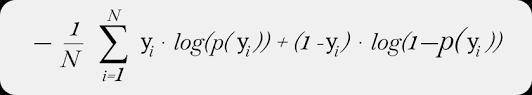

Why not MSE? While mean squared error (calculated using the formula below) could also work, BCE often works better for image reconstruction when the output pixel values are between 0 and 1 (in most cases I looked at they used BCE). This could be due to the fact that using BCE, it penalizes the model more strongly when the model is very confident and is wrong.

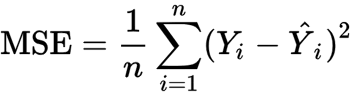

__2. KL Divergence__

This is the part that makes a VAE a generative model. The Kullback-Leibler (KL) Divergence (calculated by the formula below) acts as a regularizer on the latent space. Its goal is to force the distributions learned by the encoder to be as close as possible to a standard normal distribution. Without it the encoder would learn to memorize the training data by placing each image in its own isolated point in the latent space. We want the latent space to resemble a gaussian distribution so we can later sample from this space and generate new images that look similar to the original dataset.

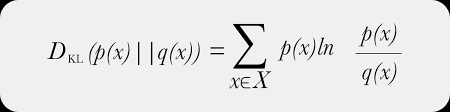

These two losses are then combined in a __total loss__, which is calculated using the formula below, to strike a balance between preserving the information of the input (being a perfect autoencoder) and having a well organized latent space.

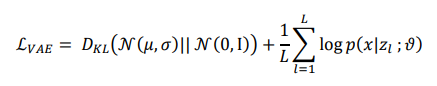

In [4]:
import torch.nn.functional as F

def vae_loss_function(reconstructed_x, x, mu, logvar, kl_weight=1.0):
    recon_loss = F.binary_cross_entropy(
        reconstructed_x, 
        x, 
        reduction='mean'
    )
    
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    num_pixels = x.size(1) * x.size(2) * x.size(3)
    kld = kld / (x.size(0) * num_pixels)
    
    total_loss = recon_loss + (kl_weight * kld)
    
    return total_loss, recon_loss, kld

## 2-4. Training the model

In this section we are going to train the model defined above according to the process described in the 4.A section of the paper

We will first load back the processed data we created earlier and define the hyper parameters we are going to use to train the model.

Something to note here is that the paper used 5000 epochs to train the model, but due to time and hardware constraints we are going to perform fewer epochs.

* I also wanted to use a test and validation dataset but since the question stated we should only make one dataset we only have a train dataset

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 128
epochs = 100
latent_dim = 6

Using device: cuda


For our training we are only using the normal images. The idea behind it is to train the VAE exclusively on healthy images and make it and expert on re-creating those so when we feed it polyp images in the later sections it would be used for evaluation (as anomaly detection). When we give the model polyp images it would use its limited knowledge to create something it has not seen before so it will likely generate a blurry or distorted version and try to make the polyp look like healthy tissue. The high reconstruction error is also expected and how we can detect these anomalies.

In [6]:
from torch.utils.data import DataLoader, Dataset

class NormalImageDataset(Dataset):
    def __init__(self, directory):
        self.directory = directory
        self.file_list = [f for f in os.listdir(directory) if f.endswith('.pt')]

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = os.path.join(self.directory, self.file_list[idx])
        tensor = torch.load(file_path)
        return tensor

normal_dataset_path = './processed/normal'
train_dataset = NormalImageDataset(directory=normal_dataset_path)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4 
)

print(len(train_dataset))

1500


In [7]:
import torch.optim as optim
import os
from tqdm import tqdm
import numpy as np

def train_model(model, train_loader, optimizer, epochs, device, kl_weight=1.0):
    history = {
        'total_loss': [],
        'recon_loss': [],
        'kld_loss': []
    }
    best_loss = np.inf
    
    os.makedirs('./checkpoints', exist_ok=True)
    
    print("Starting training")
    for epoch in range(epochs):
        model.train()
        
        total_train_loss = 0
        total_recon_loss = 0
        total_kld_loss = 0
        
        for data in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            data = data.to(device)
            reconstructed_x, original_x, mu, logvar = model(data)
            
            loss, recon_loss, kld = vae_loss_function(
                reconstructed_x, original_x, mu, logvar, kl_weight
            )
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kld_loss += kld.item()
            
        avg_loss = total_train_loss / len(train_loader)
        avg_recon_loss = total_recon_loss / len(train_loader)
        avg_kld = total_kld_loss / len(train_loader)
        
        history['total_loss'].append(avg_loss)
        history['recon_loss'].append(avg_recon_loss)
        history['kld_loss'].append(avg_kld)
        
        print(f"Epoch [{epoch+1}/{epochs}] -> Avg Loss: {avg_loss:.4f}, Recon Loss: {avg_recon_loss:.4f}, KL Div: {avg_kld:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"New best model saved with loss: {best_loss:.4f}")
            
        if (epoch + 1) % 50 == 0:
            checkpoint_path = f'./checkpoints/model_epoch_{epoch+1}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Checkpoint saved to {checkpoint_path}")
            
    return history

#### Test 1
Since after training we saw poor image qualities and KL Div loss was quite low compared to Recon loss, We've increased the weight of it to fine tune the model. but even after extensive fine tuning and even running the model for 5000 epochs the results were less than desirable

In [8]:
learning_rate = 1e-5
epochs = 5000

model = EndoVAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

loss_history = train_model(model, train_loader, optimizer, epochs=epochs, device=device, kl_weight=1)

Starting training


Epoch [1/5000] -> Avg Loss: 0.6932, Recon Loss: 0.6932, KL Div: 0.0000
New best model saved with loss: 0.6932


Epoch [2/5000] -> Avg Loss: 0.6925, Recon Loss: 0.6925, KL Div: 0.0000
New best model saved with loss: 0.6925


Epoch [3/5000] -> Avg Loss: 0.6918, Recon Loss: 0.6918, KL Div: 0.0000
New best model saved with loss: 0.6918


Epoch [4/5000] -> Avg Loss: 0.6910, Recon Loss: 0.6910, KL Div: 0.0000
New best model saved with loss: 0.6910


...

Epoch [4996/5000] -> Avg Loss: 0.5989, Recon Loss: 0.5979, KL Div: 0.0010


Epoch [4997/5000] -> Avg Loss: 0.5987, Recon Loss: 0.5977, KL Div: 0.0010


Epoch [4998/5000] -> Avg Loss: 0.5989, Recon Loss: 0.5979, KL Div: 0.0010


Epoch [4999/5000] -> Avg Loss: 0.5987, Recon Loss: 0.5977, KL Div: 0.0010


Epoch [5000/5000] -> Avg Loss: 0.5987, Recon Loss: 0.5977, KL Div: 0.0010
Checkpoint saved to ./checkpoints/model_epoch_5000.pth


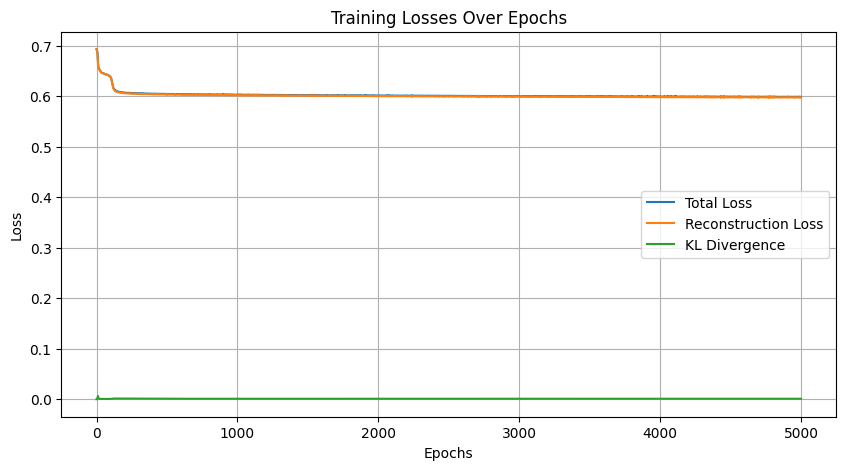

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history['total_loss'], label='Total Loss')
plt.plot(loss_history['recon_loss'], label='Reconstruction Loss')
plt.plot(loss_history['kld_loss'], label='KL Divergence')
plt.title('Training Losses Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

We can see that after maybe 500 epochs the loss didn't have a significant change.

#### Test 2

We will also showcase another configuration that had the best results amongst the tested hyperparameters.

In [29]:
learning_rate = 1e-3
epochs = 500

model = EndoVAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

loss_history = train_model(model, train_loader, optimizer, epochs=epochs, device=device, kl_weight=0.001)

Starting training


Epoch [1/500] -> Avg Loss: 1.4835, Recon Loss: 1.4832, KL Div: 0.3661
New best model saved with loss: 1.4835


Epoch [2/500] -> Avg Loss: 0.6654, Recon Loss: 0.6654, KL Div: 0.0000
New best model saved with loss: 0.6654


Epoch [3/500] -> Avg Loss: 0.6542, Recon Loss: 0.6542, KL Div: 0.0000
New best model saved with loss: 0.6542


Epoch [4/500] -> Avg Loss: 0.6530, Recon Loss: 0.6530, KL Div: 0.0000
New best model saved with loss: 0.6530


...

Epoch [496/500] -> Avg Loss: 0.5952, Recon Loss: 0.5952, KL Div: 0.0129


Epoch [497/500] -> Avg Loss: 0.5946, Recon Loss: 0.5945, KL Div: 0.0129


Epoch [498/500] -> Avg Loss: 0.5944, Recon Loss: 0.5944, KL Div: 0.0127


Epoch [499/500] -> Avg Loss: 0.5939, Recon Loss: 0.5939, KL Div: 0.0127


Epoch [500/500] -> Avg Loss: 0.5939, Recon Loss: 0.5939, KL Div: 0.0127
Checkpoint saved to ./checkpoints/model_epoch_500.pth


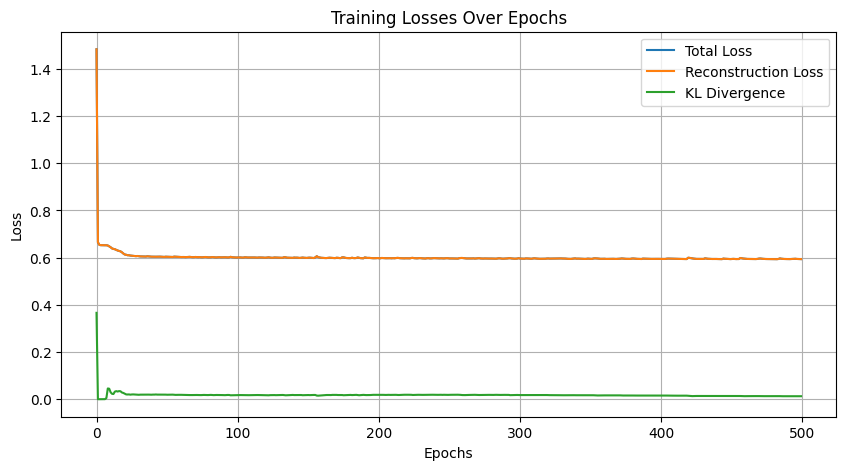

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history['total_loss'], label='Total Loss')
plt.plot(loss_history['recon_loss'], label='Reconstruction Loss')
plt.plot(loss_history['kld_loss'], label='KL Divergence')
plt.title('Training Losses Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 2-5. Qualitative generation and reconstruction

In this part we are going to visualise a few instances of newly generated images from a random number and the reconstruction ability of the model when given unseen polyp images.

### 2-5-1. Generation

We will now generate 9 random numbers from the standard normal distribution and give them to the decoder part of the model and visualise the generated images in a 3x3 grid.

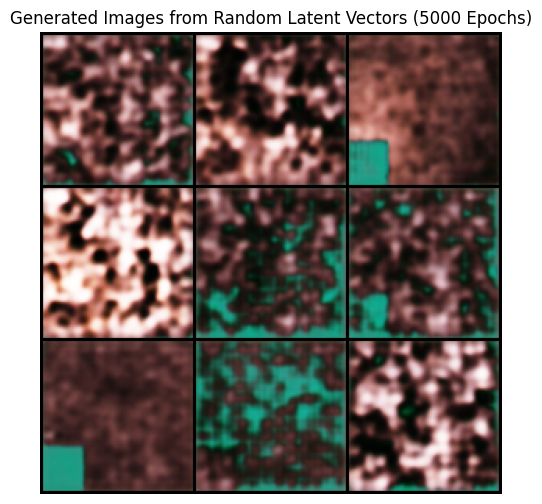

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EndoVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('best_model_5000_epoch.pth', map_location=device))
model.eval()

import torchvision

with torch.no_grad(): 
    num_images = 9
    z = torch.randn(num_images, latent_dim).to(device)
    
    generated_images = model.decoder(model.decoder_input(z).view(-1, 256, 12, 12))

grid = torchvision.utils.make_grid(generated_images.cpu(), nrow=3)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.title("Generated Images from Random Latent Vectors (5000 Epochs)")
plt.axis('off')
plt.show()

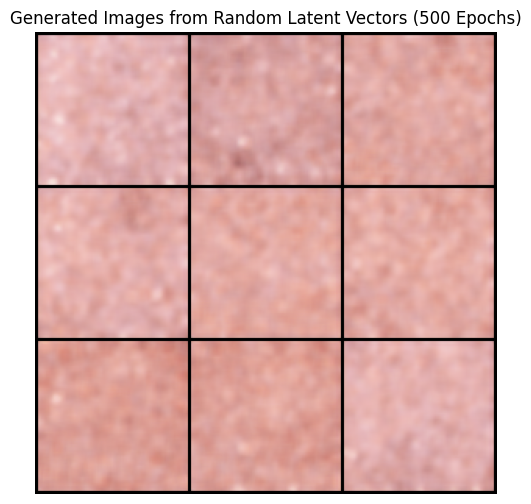

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EndoVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('checkpoints/model_epoch_500.pth', map_location=device))
model.eval()

import torchvision

with torch.no_grad(): 
    num_images = 9
    z = torch.randn(num_images, latent_dim).to(device)
    
    generated_images = model.decoder(model.decoder_input(z).view(-1, 256, 12, 12))

grid = torchvision.utils.make_grid(generated_images.cpu(), nrow=3)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.title("Generated Images from Random Latent Vectors (500 Epochs)")
plt.axis('off')
plt.show()

As we can see despite extensive fine tuning and running the code for 5000 epochs and keeping the best model we cans se the model's performance was quite low.

### 2-5-2. Reconstruction

Next we will give the model some images containing polyp and see its reconstruction capabilities.

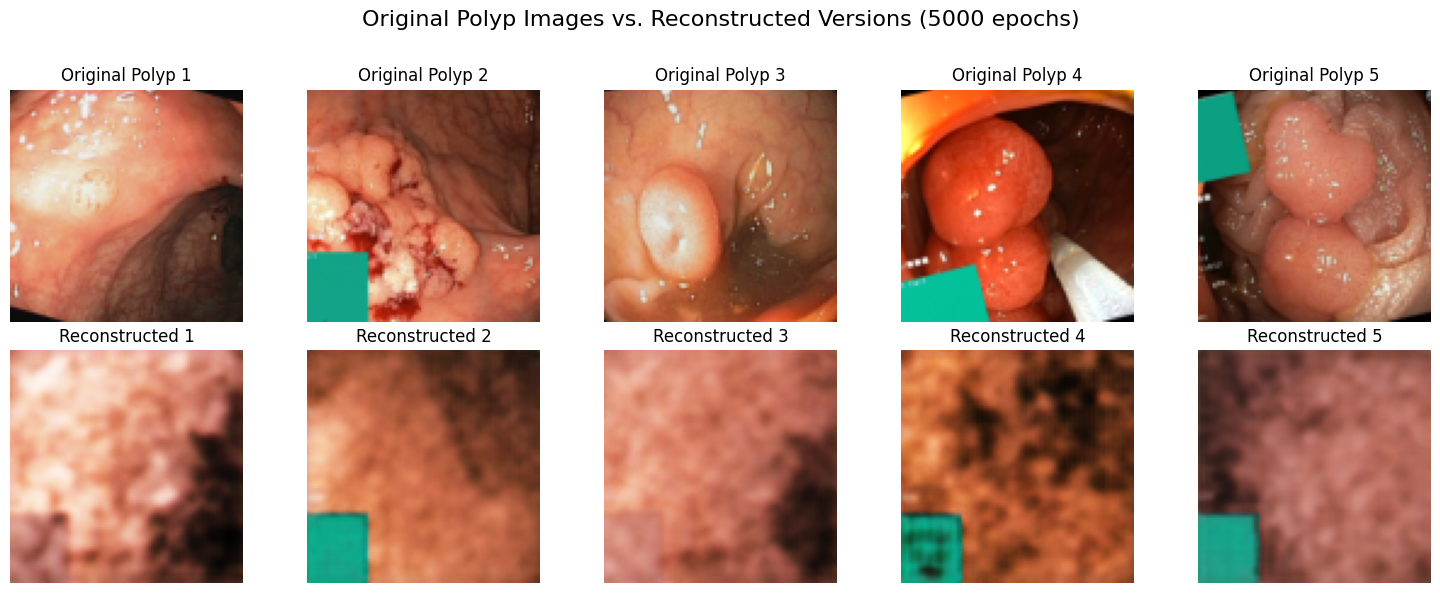

In [32]:
model = EndoVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('best_model_5000_epoch.pth', map_location=device))
model.eval()

processed_polyp_path = './processed/polyp'
polyp_files = [f for f in os.listdir(processed_polyp_path) if f.endswith('.pt')]
selected_files = random.sample(polyp_files, 5)

original_polyp_tensors = []
for file in selected_files:
    tensor = torch.load(os.path.join(processed_polyp_path, file))
    original_polyp_tensors.append(tensor)

batch = torch.stack(original_polyp_tensors).to(device)

with torch.no_grad():
    reconstructed_batch, _, _, _ = model(batch)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Original Polyp Images vs. Reconstructed Versions (5000 epochs)", fontsize=16)

for i in range(5):
    axes[0, i].imshow(original_polyp_tensors[i].permute(1, 2, 0))
    axes[0, i].set_title(f"Original Polyp {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(reconstructed_batch[i].cpu().permute(1, 2, 0))
    axes[1, i].set_title(f"Reconstructed {i+1}")
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

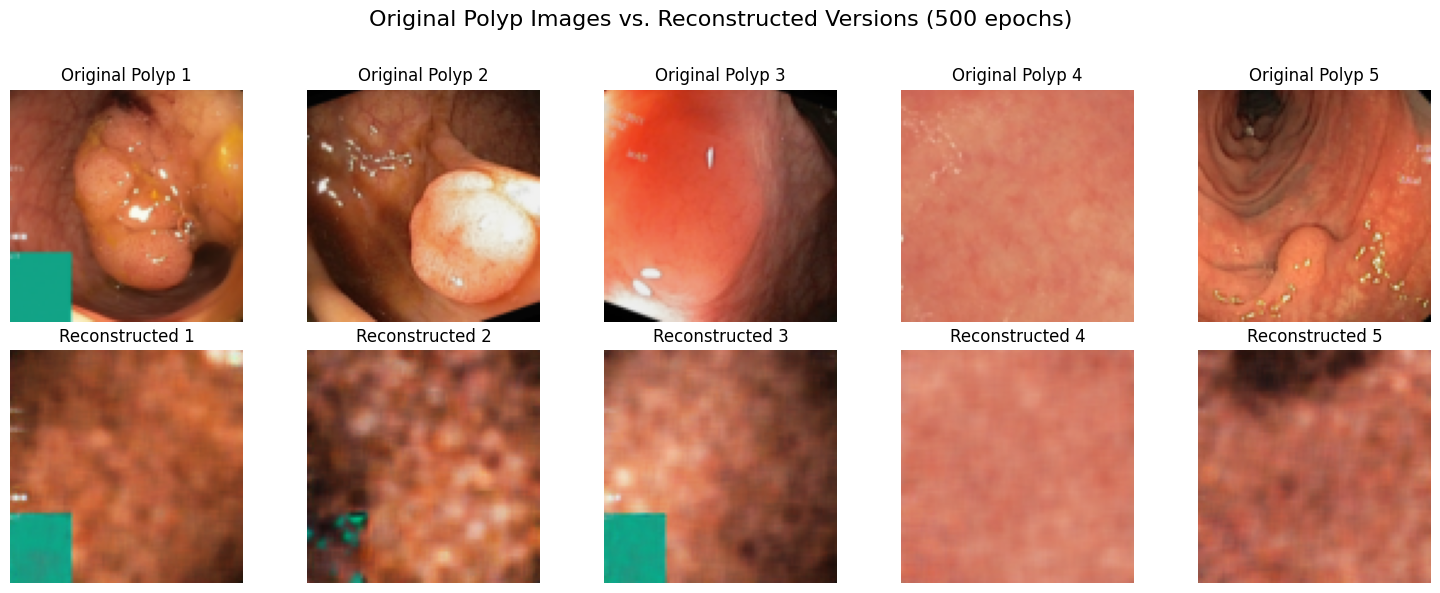

In [33]:
model = EndoVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('checkpoints/model_epoch_500.pth', map_location=device))
model.eval()

processed_polyp_path = './processed/polyp'
polyp_files = [f for f in os.listdir(processed_polyp_path) if f.endswith('.pt')]
selected_files = random.sample(polyp_files, 5)

original_polyp_tensors = []
for file in selected_files:
    tensor = torch.load(os.path.join(processed_polyp_path, file))
    original_polyp_tensors.append(tensor)

batch = torch.stack(original_polyp_tensors).to(device)

with torch.no_grad():
    reconstructed_batch, _, _, _ = model(batch)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Original Polyp Images vs. Reconstructed Versions (500 epochs)", fontsize=16)

for i in range(5):
    axes[0, i].imshow(original_polyp_tensors[i].permute(1, 2, 0))
    axes[0, i].set_title(f"Original Polyp {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(reconstructed_batch[i].cpu().permute(1, 2, 0))
    axes[1, i].set_title(f"Reconstructed {i+1}")
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Again the reconstruction capability of the model isn't that great as we can see despite the extensive training and fileting but it would be somewhat expected given it has never seen polyp images.

## 2-5. Numeric evaluation

Here we will reconstruct 50 images from the processed/polyp folder and evaluate their reconstruction with PSNR and SSIM metrics and present the results in a table.

But first lets explain these metrics briefly:

__PSNR (Peak Signal to Noise Ratio)__ measures the quality of a image by comparing the maximum pixel value to the amount of noise  (or error in our case). It measures this value in dB and a higher PSNR value means the image (reconstruction) has a higher quality and is more similar to the original one.

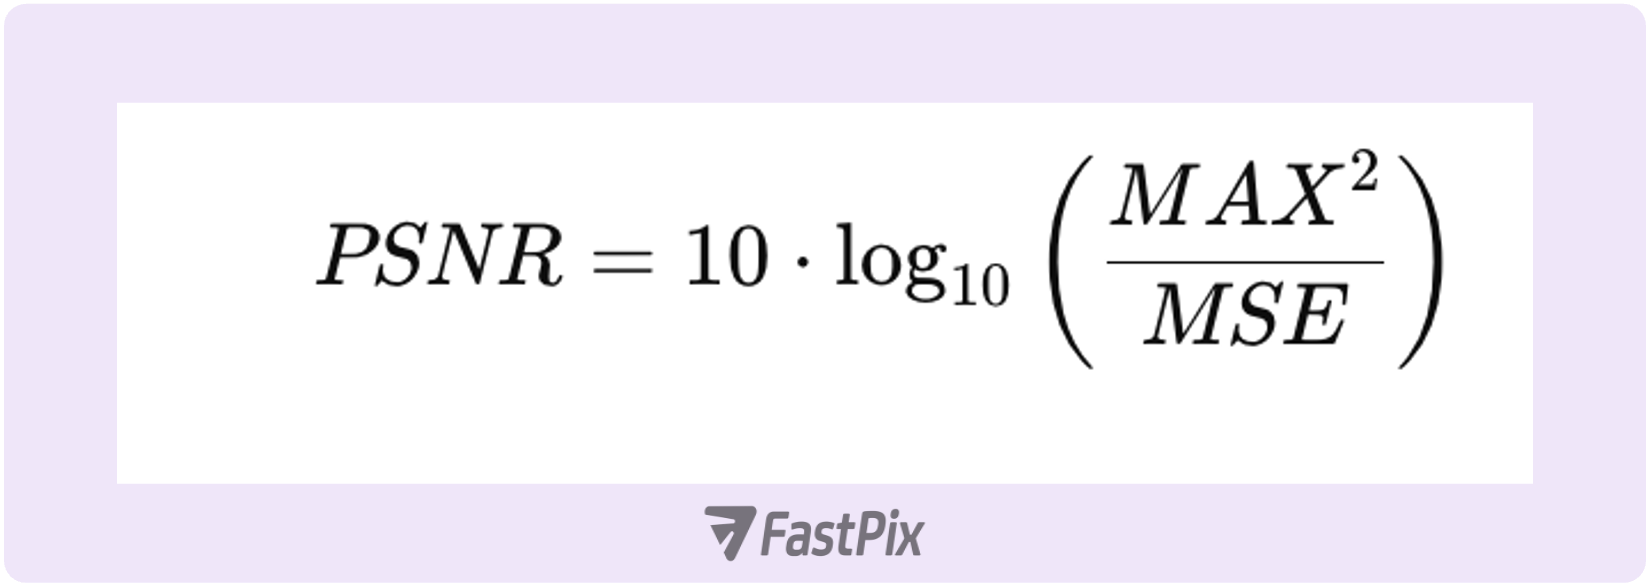

__SSIM (Structural Similarity Index Measure)__ is a more advanced metric that measures the perceptual similarity of two images. Instead of just looking at pixel-by-pixel errors like PSNR, SSIM considers changes in texture, luminance, and contrast. Its value ranges from -1 to 1. An SSIM value closer to 1 indicates a very high structural similarity.

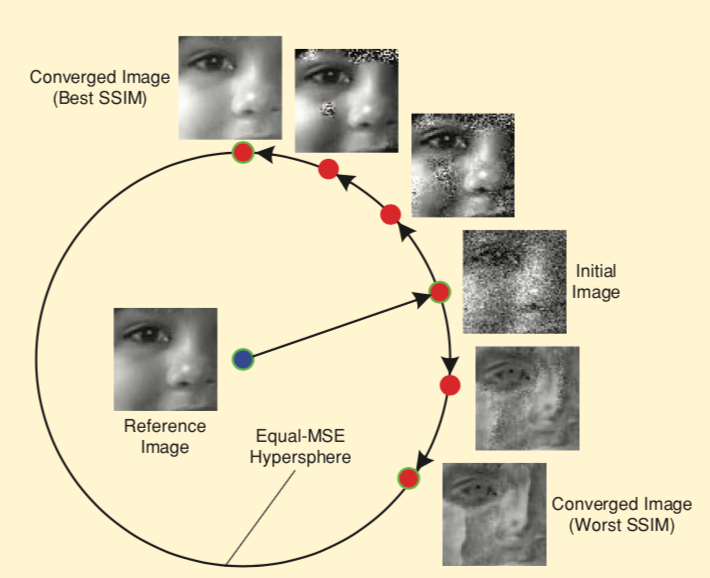

In [34]:
import pandas as pd
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_samples = 50

model = EndoVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('best_model_5000_epoch.pth', map_location=device))
model.eval()

processed_polyp_path = './processed/polyp'
polyp_files = [f for f in os.listdir(processed_polyp_path) if f.endswith('.pt')]
num_to_sample = min(num_samples, len(polyp_files))
selected_files = random.sample(polyp_files, num_to_sample)
polyp_tensors = [torch.load(os.path.join(processed_polyp_path, f)) for f in selected_files]
batch = torch.stack(polyp_tensors).to(device)

psnr_scores = []
ssim_scores = []

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

with torch.no_grad():
    reconstructed_batch, _, _, _ = model(batch)
    
    for i in tqdm(range(num_to_sample), desc="Calculating Metrics"):
        original_img = batch[i].unsqueeze(0)
        recon_img = reconstructed_batch[i].unsqueeze(0)
        
        psnr_scores.append(psnr_metric(recon_img, original_img).item())
        ssim_scores.append(ssim_metric(recon_img, original_img).item())

psnr_tensor = torch.tensor(psnr_scores)
ssim_tensor = torch.tensor(ssim_scores)

psnr_mean = psnr_tensor.mean().item()
psnr_std = psnr_tensor.std().item()

ssim_mean = ssim_tensor.mean().item()
ssim_std = ssim_tensor.std().item()

final_table_data = {
    "PSNR (dB) [Mean ± Std Dev]": [f"{psnr_mean:.2f} ± {psnr_std:.2f}"],
    "SSIM [Mean ± Std Dev]": [f"{ssim_mean:.4f} ± {ssim_std:.4f}"]
}
final_df = pd.DataFrame(final_table_data)

print(final_df.to_string(index=False))

Calculating Metrics: 100%|██████████| 50/50 [00:00<00:00, 755.06it/s]

PSNR (dB) [Mean ± Std Dev] SSIM [Mean ± Std Dev]
              16.23 ± 2.72       0.3798 ± 0.1106


In [35]:
import pandas as pd
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_samples = 50

model = EndoVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('checkpoints/model_epoch_500.pth', map_location=device))
model.eval()

processed_polyp_path = './processed/polyp'
polyp_files = [f for f in os.listdir(processed_polyp_path) if f.endswith('.pt')]
num_to_sample = min(num_samples, len(polyp_files))
selected_files = random.sample(polyp_files, num_to_sample)
polyp_tensors = [torch.load(os.path.join(processed_polyp_path, f)) for f in selected_files]
batch = torch.stack(polyp_tensors).to(device)

psnr_scores = []
ssim_scores = []

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

with torch.no_grad():
    reconstructed_batch, _, _, _ = model(batch)
    
    for i in tqdm(range(num_to_sample), desc="Calculating Metrics"):
        original_img = batch[i].unsqueeze(0)
        recon_img = reconstructed_batch[i].unsqueeze(0)
        
        psnr_scores.append(psnr_metric(recon_img, original_img).item())
        ssim_scores.append(ssim_metric(recon_img, original_img).item())

psnr_tensor = torch.tensor(psnr_scores)
ssim_tensor = torch.tensor(ssim_scores)

psnr_mean = psnr_tensor.mean().item()
psnr_std = psnr_tensor.std().item()

ssim_mean = ssim_tensor.mean().item()
ssim_std = ssim_tensor.std().item()

final_table_data = {
    "PSNR (dB) [Mean ± Std Dev]": [f"{psnr_mean:.2f} ± {psnr_std:.2f}"],
    "SSIM [Mean ± Std Dev]": [f"{ssim_mean:.4f} ± {ssim_std:.4f}"]
}
final_df = pd.DataFrame(final_table_data)

print(final_df.to_string(index=False))

Calculating Metrics: 100%|██████████| 50/50 [00:00<00:00, 813.05it/s]

PSNR (dB) [Mean ± Std Dev] SSIM [Mean ± Std Dev]
              16.30 ± 2.33       0.3966 ± 0.0831


Here we can see that both tested models, despite visual differences, got very close PSNR and SSIM values.

## 2-7. Analysis of the final results and discussion

In this section we will answer a few questions about the results.

### 2-7-1. Qualitative analysis

#### 2-7-1-1. How realistic are the generated images?

Unfortunately despite all the efforts and time spent fine tuning the model and even running it for 5000 epochs as stated in the paper, the results were less than satisfactory and wouldn't really be of any use in real world situations. They did manage to replicated the pinkish color and some black spots but overall they were very blurry and the green part of some of the input images (probably an overlay) was very promenant in the produced images.

#### 2-7-1-1. What details does the polyp reconstruction preserve and what parts are blurred?

Well under ideal circumstances (a model that can produce better results than what we have here) it would most likely preserver the color, lighting, background and texture of the image in healthy areas but it would fail to recreate the polyp itself, as the model hasn't seen it before. So the parts where the polyp exist would probably be blurry and maybe with a different texture

### 2-7-2. Quantitative analysis

#### 2-7-2-1. What do the PSNR and SSIM values indicate about the quality of the reproduced images?

These values were explained in the previous sections so I will just copy and paste the explanation here:

Here we will reconstruct 50 images from the processed/polyp folder and evaluate their reconstruction with PSNR and SSIM metrics and present the results in a table.

But first lets explain these metrics briefly:

__PSNR (Peak Signal to Noise Ratio)__ measures the quality of a image by comparing the maximum pixel value to the amount of noise  (or error in our case). It measures this value in dB and a higher PSNR value means the image (reconstruction) has a higher quality and is more similar to the original one.

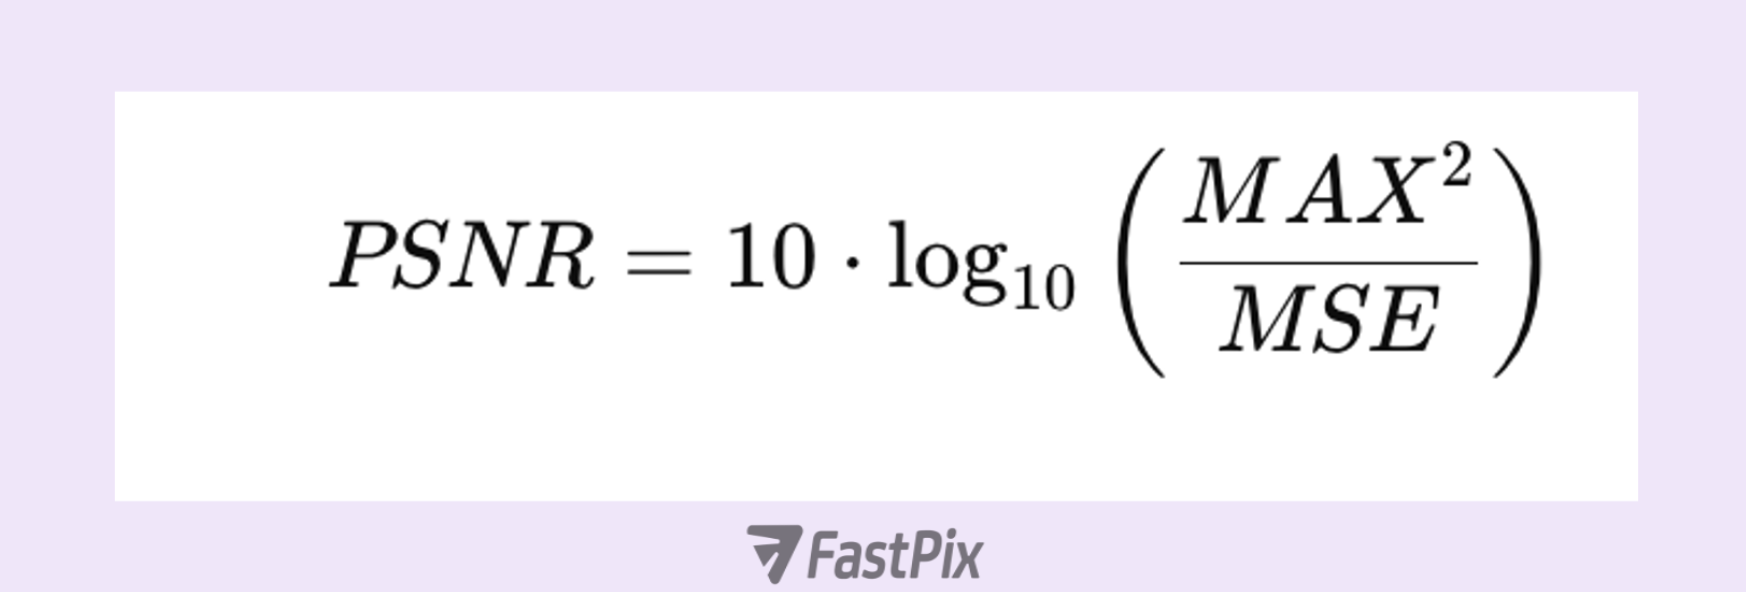

__SSIM (Structural Similarity Index Measure)__ is a more advanced metric that measures the perceptual similarity of two images. Instead of just looking at pixel-by-pixel errors like PSNR, SSIM considers changes in texture, luminance, and contrast. Its value ranges from -1 to 1. An SSIM value closer to 1 indicates a very high structural similarity.

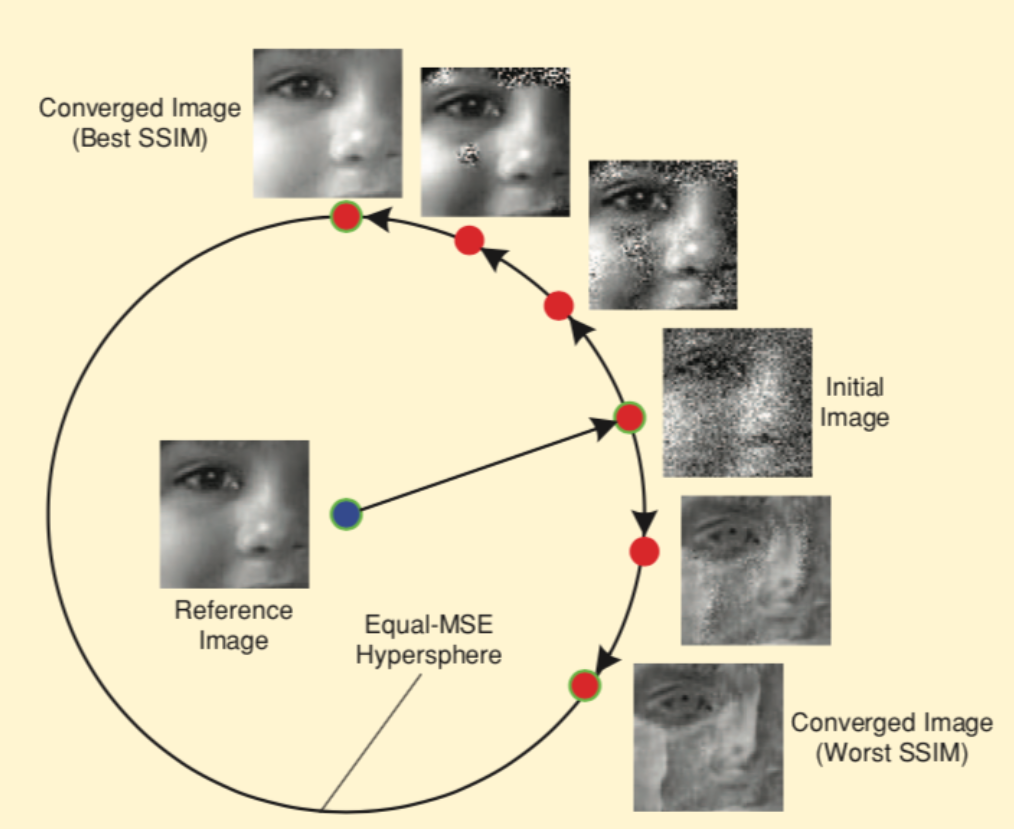

#### 2-7-2-1. If the PSNR and SSIM values are low, which part of the architecture, hyperparameters, or preprocessing is likely the problem?

Given the fact that we are using a different dataset form the paper and the model has never seen polyp images somewhat of a low value is to be excepted. But in order to improve the performance we can change the following aspects: (hyper parameter tuning was performed extensively so it's not likely it is the main issue!)

__Training Data__: The most obvious issue is that we are using a different data set from the paper, furthermore the model was never trained on polyp images so to improve polyp reconstruction, we would need to include them in the training set. Also using more training data or more aggressive data augmentation would be beneficial.

__Loss Function Weighting__: The balance between the reconstruction loss and the KL divergence is critical. A higher kl_weight (or β) forces a more structured latent space at the cost of reconstruction quality, leading to lower PSNR/SSIM. A lower weight would improve reconstruction but might harm generative quality, however this has been tested during our training and unfortunately didn't help much as the kl loss would quickly go to 0!

__Model Capacity__: A deeper or wider VAE architecture could potentially capture more detail and better reconstructions and higher scores.

__Latent Dimension__: A larger latent_dim could allow the model to store more information about the images, potentially improving reconstruction quality at the risk of making the latent space harder to organize.

## 2-8. Bonus section

In this section we are going to define a simple CNN classifier and train to to distinguish between real polyp images and reconstructed polyp images. Given the rather low quality of reconstruction we expect the model get near perfect accuracy!

### 2-8-1. Making the dataset

We will first create the dataset and split it into 80% train and 20% test

In [37]:
from torch.utils.data import TensorDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EndoVAE(latent_dim=6).to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

num_pairs = 200
processed_polyp_path = './processed/polyp'
polyp_files = [f for f in os.listdir(processed_polyp_path) if f.endswith('.pt')]
selected_files = random.sample(polyp_files, min(num_pairs, len(polyp_files)))

real_images = torch.stack([torch.load(os.path.join(processed_polyp_path, f)) for f in selected_files]).to(device)

with torch.no_grad():
    reconstructed_images, _, _, _ = model(real_images)

real_labels = torch.ones(real_images.size(0), 1)
recon_labels = torch.zeros(reconstructed_images.size(0), 1)

all_images = torch.cat([real_images.cpu(), reconstructed_images.cpu()])
all_labels = torch.cat([real_labels, recon_labels])

dataset = TensorDataset(all_images, all_labels)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### 2-8-2. Making and training the CNN

Then we define a simple cnn classifier and train it

In [41]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 12 * 12, 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) 
        x = self.fc_layers(x)
        return x

classifier = CNN().to(device)
optimizer = optim.Adam(classifier.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(15):
    classifier.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/15], Loss: {loss.item():.4f}")

print("Classifier training complete.")

Epoch [1/15], Loss: 0.6867
Epoch [2/15], Loss: 0.6626
Epoch [3/15], Loss: 0.5849
Epoch [4/15], Loss: 0.4908
Epoch [5/15], Loss: 0.2643
Epoch [6/15], Loss: 0.4192
Epoch [7/15], Loss: 0.3024
Epoch [8/15], Loss: 0.2266
Epoch [9/15], Loss: 0.1216
Epoch [10/15], Loss: 0.1473
Epoch [11/15], Loss: 0.0768
Epoch [12/15], Loss: 0.2256
Epoch [13/15], Loss: 0.2888
Epoch [14/15], Loss: 0.1813
Epoch [15/15], Loss: 0.1999
Classifier training complete.


### 2-8-3. Evaluating the CNN

And finally we will evaluate the model by calculating its accuracy and AUC

In [43]:
from sklearn.metrics import accuracy_score, roc_auc_score

classifier.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        
        all_preds.extend(outputs.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

accuracy = accuracy_score(np.round(all_true), np.round(all_preds))
auc = roc_auc_score(all_true, all_preds)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"AUC: {auc:.4f}")

Accuracy: 93.75%
AUC: 0.9925


As we can see the accuracy is 93% and AUC is near 1 showing that reconstruction capabilities of the model were'nt nearly enough to fool the classifier and cannot be used as a replacement of our dataset (to train robust classifiers!)